In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size ='5' color='black'>ch.10 N차원 배열 다루기</font>
- N차원 배열 객체 : 동일 자료형의 집합
- 2차원 배열 ; 행렬과 비슷한 개념
- [NumPy](https://numpy.org/)
- [NumPy API Docs](https://numpy.org/doc/stable/reference/index.html)


# 1. 넘파이 패키지
## 1.1 배열 속성
- NumPy 함수들은 기본적으로 원본을 건드리지 않고 새로운 배열(혹은 View)을 반환하는 것이 원칙 
- 원본을 직접 바꾸는 건 resize(), arr.sort(), 그리고 += 같은 대입 연산

In [3]:
import numpy as np
np.__version__ # tensorflow 2.10 호환 버전

'1.23.5'

In [6]:
# np.arange(from,stop,by) : from부터 stop 전까지 by씩 증가하는 1차원 정수 배열 생성
a = np.arange(15)
print(a.shape) # 배열 구조 및 차원 확인 ; 15 길이를 가진 1차원 배열을 확인
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [24]:
from numpy import arange
a = np.arange(15, dtype=np.int8) #dtype 기본값 : int32
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int8)

In [25]:
type(a)

numpy.ndarray

In [26]:
a.dtype # a 배열의 요소(element)들의 type

dtype('int8')

In [27]:
from numpy import arange
a = np.arange(15).reshape(3,5) # 1행 15열의 1차원 배열을 3행 5열의 2차원 배열로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [20]:
a.itemsize # item 하나의 bytesize

4

In [22]:
a.ndim # 차원 수 확인

2

In [28]:
a.reshape(5,3) # 배열의 구조를 바꾸는게 아닌, 외형만 수정해 출력.

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

## 1.2 배열 타입 변경

In [29]:
a = np.arange(12).reshape(3,4)

In [32]:
a.size, a.dtype, a.itemsize

(12, dtype('int32'), 4)

In [35]:
a.dtype = np.int64
a.dtype, a.itemsize#32bit->64bit 변경되며 itemsize 변경됨

(dtype('int64'), 8)

In [36]:
a 
# 2개의 열이 하나로 합쳐짐(스택) 
# -> 00000001/00000002 [1, 2]
# -> 0000000100000002 [4294967296]
# 스택으로 합쳐진 16진수가 10진수로 표기됨

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [37]:
a.size

6

In [38]:
a = np.arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [40]:
a = a.astype(np.int64)#32bit->64bit
a.dtype

dtype('int64')

In [41]:
a.itemsize

8

In [42]:
a.ravel() # flaten된 배열을 반환

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [43]:
a.flatten()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) / npy(넘파이 포맷, io 개선)

In [167]:
%%time
import time
# start = time.time()
import pickle
with open('data/ch10.pkl', 'wb') as f:
    pickle.dump(a, f)
# end = time.time()
# print('실행 시간 :', end - start)

CPU times: total: 0 ns
Wall time: 1.18 ms


In [168]:
%%time
with open('data/ch10.pkl', 'rb') as f:
    loaded_a = pickle.load(f) # 용량 : 269 B

CPU times: total: 0 ns
Wall time: 13.5 ms


In [170]:
np.all(loaded_a==a)

True

In [166]:
%%time
np.save('data/ch11.npy', a) #넘파이 포맷, 효율 및 안정성 개선, 용량 : 248 B

CPU times: total: 0 ns
Wall time: 2.42 ms


In [56]:
%%time
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 15.6 ms
Wall time: 14.1 ms


In [57]:
loaded_a2 == a

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

# 2. 넘파이 배열
- array() 함수를 이용한 파이썬 데이터(list, tuple) 변환
- 특정 값을 갖는 배열 생성 함수 : ones(), zeros(), empty(), full(), ...
- 랜덤한 값을 갖는 배열 생성 함수 : random.normal() ...
- [NumPy Func](https://numpy.org/doc/stable/reference/index.html)

## 2.1 array() 함수
- array(obj, dtype=np.type(or 'type'), copy=T/F) ; obj:list
    * type : int32, int64, float32, float64, ...

In [59]:
a = np.array([2, 14, 6],
            # dtype=np.int16
            ) # 정수의 기본 타입 : int32 / 실수의 기본 타입 : float64
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [60]:
a[0], a[1]

(2, 14)

In [63]:
for item in a: # 일반적인 list 데이터 탐색과 같음
    print(item, end=' ')

2 14 6 

In [65]:
b = np.array([[1.4, 3.2], # 동일 자료형의 집합으로 배열 생성. 우선 순위 : 정수 → 실수 → 문자
            [3, 5]])
b, b.dtype

(array([[1.4, 3.2],
        [3. , 5. ]]),
 dtype('float64'))

In [73]:
l = [[1.5, 2.3],[4, 5]]
l[0][1]

2.3

In [67]:
b[0,1] # 2차원 [axis0 : 행, axis1 : 열] cf. 1차원 [axis0 : 열]

3.2

In [75]:
a = np.array([[1.5,3.2],
              [4,5]], dtype='float32').reshape(4)
a

array([1.5, 3.2, 4. , 5. ], dtype=float32)

In [78]:
# a의 배열 구조 변경
a.shape = (2, 2)
a

array([[1.5, 3.2],
       [4. , 5. ]], dtype=float32)

In [80]:
#a의 dtype 변경
a = a.astype('float16')
a.dtype

dtype('float16')

In [103]:
for row in a:
    for item in row:
        print(item, end=' ')
    print()

1.5 3.2 
4.0 5.0 


In [104]:
for i, row in enumerate(a):
    for j, item in enumerate(row):
        print(f'[{i}][{j}] {a[i,j]}', end='\t') #float16 : 소수점 이하 불안정
    print()

[0][0] 1.5	[0][1] 3.19921875	
[1][0] 4.0	[1][1] 5.0	


In [101]:
print(b[0,0])
# print(b[0,2]) 존재하지 않는 index 출력은 에러 발생

1.4


In [127]:
# 행과 열의 슬라이싱 : 2차원 배열 데이터 반환
b[:, 1:10] # 전체 행에서 1열부터 10열 전까지 슬라이싱

array([[3.2],
       [5. ]])

In [130]:
# 특정 행(열)의 슬라이싱 : 1차원 배열 데이터 반환
b[0, 1:3] # 0행의 1열부터 3열 전까지 슬라이싱

array([3.2])

In [114]:
ex = np.array([[1,2,3],
              [6,7,8]])

In [125]:
# 모든 행의 마지막 열만 추출
ex[:,-1:], ex[:,-1]

(array([[3],
        [8]]),
 array([3, 8]))

In [128]:
# 모든 행의 마지막 열을 제외한 부분 추출
ex[:,:-1:]

array([[1, 2],
       [6, 7]])

In [132]:
# 스칼라 변수에서
a = 10
b = a
id(a), id(b)

(2525653762576, 2525653762576)

In [147]:
# 스칼라 변수에서
a = 10
b = -1
print(id(a), id(b))

2525653762576 2525653762224


In [146]:
# NumPy 배열에서
c = np.array([[1,2,3],[4,5,6]], dtype='int16') 
d = c #할당.
print(id(c), id(d))

2525806981552 2525806981552


In [151]:
# NumPy 배열에서
c = np.array([[1,2,3],[4,5,6]], dtype='int16') 
d = np.array(c, copy=False) # 할당. d 내용 수정 시 원본 c에도 영향.
print(id(c), id(d))
d[0,0]=9
print(c, d, sep='\n')

2525806980016 2525806980016
[[9 2 3]
 [4 5 6]]
[[9 2 3]
 [4 5 6]]


In [152]:
# NumPy 배열에서
c = np.array([[1,2,3],[4,5,6]], dtype='int16') 
d = np.array(c, copy=False, dtype='int8') # copy=False인 상태에서, dtype이 바뀌면 깊은 복사로 변경됨
print(id(c), id(d))
d[0,0]=9
print(c, d, sep='\n')

2525806969840 2525806980688
[[1 2 3]
 [4 5 6]]
[[9 2 3]
 [4 5 6]]


In [149]:
# NumPy 배열에서
c = np.array([[1,2,3],[4,5,6]], dtype='int16') 
d = np.array(c, copy=True) # 내용을 복사한 독립개체 ; Deep Copy - c.copy()와 동일
print(id(c), id(d))
d[0,0]=9
print(c, d, sep='\n')

2525806980016 2525806979824
[[1 2 3]
 [4 5 6]]
[[9 2 3]
 [4 5 6]]


정보처리에서, u'type' : unsigned 'type' <br>
int8에서 1은 `00000001`으로 표기. <br>
제일 앞의 0은 부호 표기를 담당. (0:+,1:-) <br>
따라서, 1의 경우 `11111110`으로 표기. <br>
unsigned는 해당 이진수를 양수로 읽으므로 uint8에서 -1은 10진수 254를 의미함.

## 2.2 기본값이 있는 배열
- np.zeros(tup, dtype) : 0.0으로 채우기
- np.ones(tup, dtype) : 1.0으로 채우기
- np.full(tup, def, dtype) : def으로 채우기
- np.empty(tup, dtype) : 임의의 값으로 채우기

**위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64으로 설정됨.**

In [206]:
np.zeros((3,5)) # 3행 5열의 2차원 float64 배열에 모든 요소를 0.0으로

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [209]:
np.zeros(5) # 5열의 1차원 float64 배열에 모든 요소를 0.0으로

array([0., 0., 0., 0., 0.])

In [210]:
x = np.zeros((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [213]:
np.ones((4,5), dtype='int16') # 4행 5열의 2차원 int16 배열에 모든 요소를 1으로

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=int16)

In [214]:
np.ones(5) # 5열의 1차원 float64 배열에 모든 요소를 0.0으로

array([1., 1., 1., 1., 1.])

In [216]:
x = np.ones((2,5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [223]:
x = np.full((4,5), 100, dtype='int32')
print(x)
print(x.dtype)

[[100 100 100 100 100]
 [100 100 100 100 100]
 [100 100 100 100 100]
 [100 100 100 100 100]]
int32


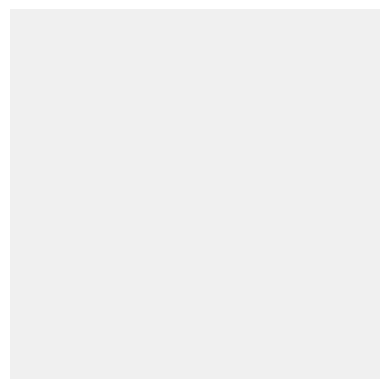

In [233]:
import matplotlib.pyplot as plt
img = np.full((70,70), 240, dtype=np.uint8)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

In [246]:
np.empty((3,8))

array([[-0.25, -0.5 ,  0.  , -0.25,  0.25, -0.5 ,  0.5 , -0.25],
       [ 0.25,  0.  ,  0.5 ,  0.25,  0.25,  0.5 ,  0.  ,  0.25],
       [-0.25,  0.5 , -0.5 ,  0.25, -0.25,  0.  , -0.5 , -0.25]])

## 2.3 랜덤한 값을 갖는 배열
- np.random.random(tup) : 0 이상 1 미만의 균일한 확률을 가진 무작위 실수
- np.random.uniforn(low, high, size=tup) : low 이상 high 미만의 균일한 확률을 가진 무작위 실수
- np.random.normal(loc, scale, size=tup) : 평균 loc, 표준편차 scale을 가진 정규분포의 무작위 실수
<br><br>
- np.random.rand(n) : 균등분포의 1차원 n개 난수 배열 생성
- np.random.randn(n) : 표준정규분포(평균 0, 표준편차 1)의 1차원 n개 난수 배열 생성
- np.random.randint(n) : 0 이상 n 미만의 정수 난수 1개 발생 == random.randint(1, n-1)
- np.random.randint(low, high, size=tup) : low 이상 high 미만 균일한 확률을 가진 무작위 정수

In [248]:
np.random.random((2,4))

array([[0.21789822, 0.43530375, 0.00162448, 0.34877898],
       [0.17107128, 0.60318086, 0.25228478, 0.80978063]])

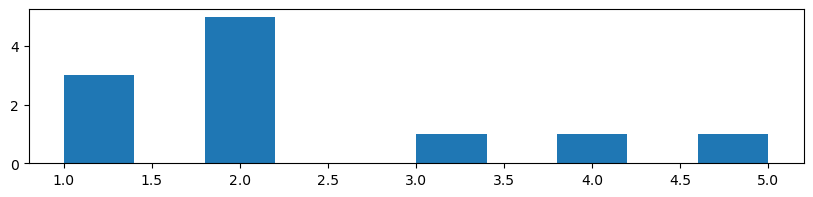

In [258]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,2)) # 그래프 사이즈 조절
x = [1, 1, 1, 2, 2, 2, 2, 5, 3, 2, 4]
plt.hist(x, bins=10) # 그래프의 촘촘한 정도
plt.show()

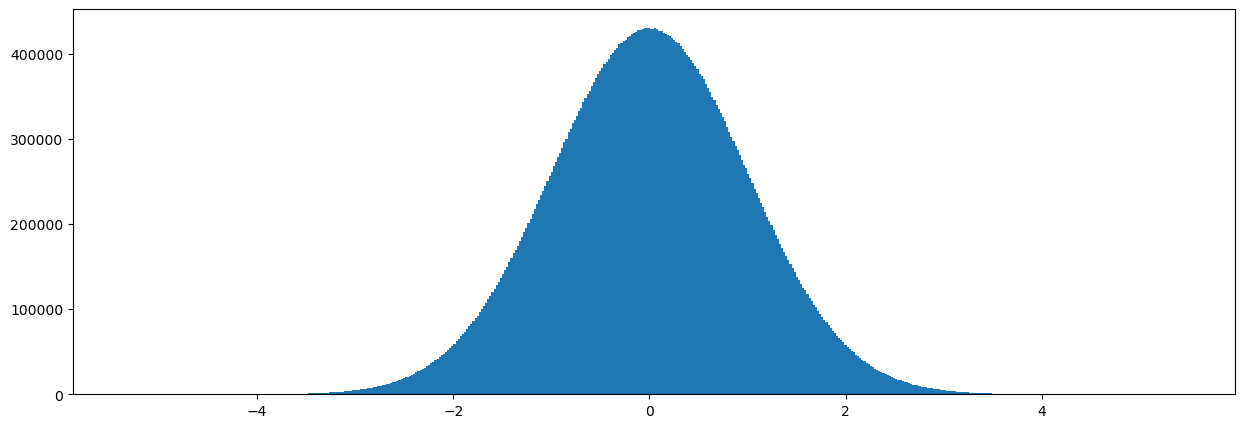

CPU times: total: 1.62 s
Wall time: 1.66 s


In [331]:
%%time
import matplotlib.pyplot as plt
plt.figure(figsize = (15,5))
x = np.random.randn(50000000)
plt.hist(x, bins=500)
plt.show()

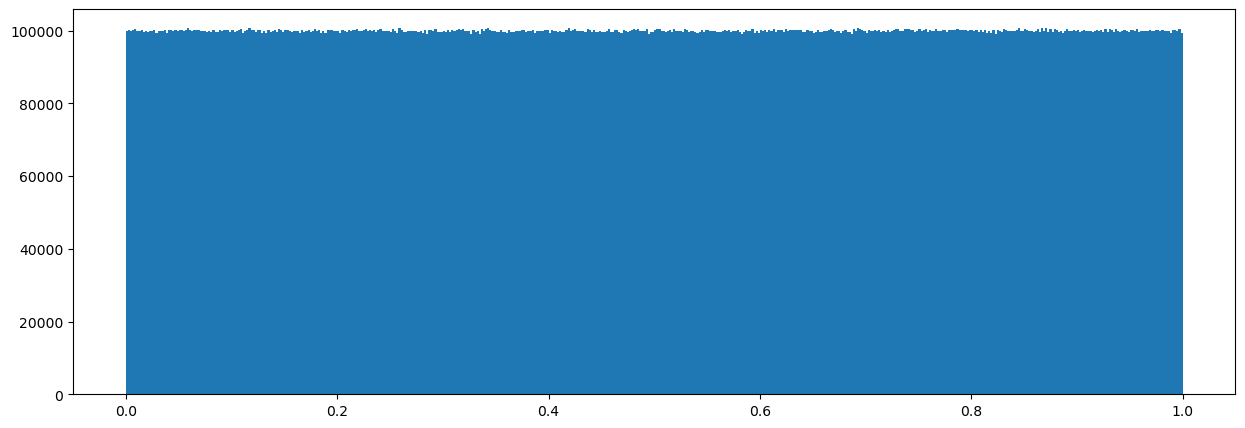

In [334]:
plt.figure(figsize = (15,5))
x =  np.random.rand(50000000)
plt.hist(x, bins=500)
plt.show()

# 4. 복사와 뷰

## 4.1 할당

In [154]:
# 스칼라 변수에서
a = 10
b = a
print('a와 b 주소 :', id(a), id(b))

b = 9
print('a와 b 주소 :', id(a), id(b))
print('수정 후 데이터 :', a, b)

a와 b 주소 : 2525653762576 2525653762576
a와 b 주소 : 2525653762576 2525653762544
수정 후 데이터 : 10 9


In [157]:
# 배열에서
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [158]:
b = a
# b = = np.arange(12)와 같음
print(a.shape, type(a), a.ndim, id(a))
print(b.shape, type(b), b.ndim, id(b))

(12,) <class 'numpy.ndarray'> 1 2525806980592
(12,) <class 'numpy.ndarray'> 1 2525806980592


In [160]:
a is b

True

In [161]:
a == b # 요소별 비교

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [171]:
np.all(a==b) #np.all() array 배열 안의 모든 값이 True인지 여부

True

In [172]:
b.shape = (3, 4)

In [174]:
print(a)
print(b)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


## 4.2 뷰(View)
- 얕은 복사 (Shallow Copy)

In [175]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [176]:
c = a.view() #얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [181]:
print('a와 c 주소 :', id(a), id(c))

a와 c 주소 : 2525806970128 2525806977232


In [177]:
np.all(a==c)

True

In [178]:
a is c

False

In [180]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [182]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [183]:
# 배열 복사본 c의 특정 요소만 수정
c[1,::2]=-99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [184]:
a # 원본 a도 함께 수정됨

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [186]:
# 슬라이싱 시 view가 반환 (shape과 dtype 외의 변경은 원본에 영향)
a = np.array([[99, 88, 77, 85],
              [95, 83, 79, 90],
              [97, 89, 72, 92]])
X = a[:,:-1]#.view()와 동일
X

array([[99, 88, 77],
       [95, 83, 79],
       [97, 89, 72]])

In [191]:
X[0:2,-1] = 1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [95, 83,  1],
       [97, 89, -1]])

In [192]:
a # <<< view를 수정했기 때문에 원본도 수정됨.

array([[99, 88,  1, 85],
       [95, 83,  1, 90],
       [97, 89, -1, 92]])

## 4.3 깊은 복사

In [196]:
a = np.array([[99, 88, 77, 85],
              [95, 83, 79, 90],
              [97, 89, 72, 92]])
a

array([[99, 88, 77, 85],
       [95, 83, 79, 90],
       [97, 89, 72, 92]])

In [198]:
X = a[:,:-1].copy() # 슬라이싱으로 view 생성 후, 깊은 복사하여 독립된 개체 생성
X = np.array(a[:,:-1], copy=True) # 깊은 복사
X

array([[99, 88, 77],
       [95, 83, 79],
       [97, 89, 72]])

In [199]:
X[:,0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1, 77],
       [ 1,  1, 79],
       [ 1,  1, -1]])

In [200]:
a

array([[99, 88, 77, 85],
       [95, 83, 79, 90],
       [97, 89, 72, 92]])